# Experiment 10: Probability Distributions and Normal Curve Fitting on Diabetes Data

**AIM:**  
To plot empirical feature distributions and fit theoretical Normal (Gaussian) Probability Density Function (PDF) curves over continuous features of the UCI Diabetes Dataset using SciPy and Matplotlib.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, SciPy, Matplotlib, Seaborn  

---
### THEORY:
- **Normal (Gaussian) Distribution**: A continuous probability distribution characterized by a symmetric bell-shaped curve defined by mean $\mu$ and standard deviation $\sigma$:
  $$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$
- **Probability Density Function (PDF)**: Describes the relative likelihood for a continuous random variable to take on a given value.
- **Kernel Density Estimation (KDE)**: A non-parametric way to estimate the probability density function of a random variable.

---
### PROCEDURE:
1. Load the UCI Diabetes Dataset (`uci_diabetes.csv`).
2. Extract continuous numerical features: `Glucose`, `BloodPressure`, `BMI`, `Age`.
3. Compute sample mean ($\mu$) and standard deviation ($\sigma$) for each metric.
4. Generate histogram density distributions with empirical KDE curves.
5. Compute theoretical Gaussian PDF curves using `scipy.stats.norm.pdf` and overlay them.
6. Compare observed clinical distributions against standard normality assumptions.

## 1. Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

uci_diabetes = pd.read_csv('uci_diabetes.csv')
print('UCI Diabetes Dataset loaded successfully!')
print(uci_diabetes.head())

UCI Diabetes Dataset loaded successfully!
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6       98             58  ...                     0.430   43        0
1            2      112             75  ...                     0.148   21        0
2            2      108             64  ...                     0.158   21        0
3            8      107             80  ...                     0.856   34        0
4            7      136             90  ...                     0.210   50        0

[5 rows x 9 columns]


## 2. Normal Curve Fitting on Glucose Distribution

Glucose Statistics -> Mean (mu): 119.95, Std Dev (sigma): 31.38


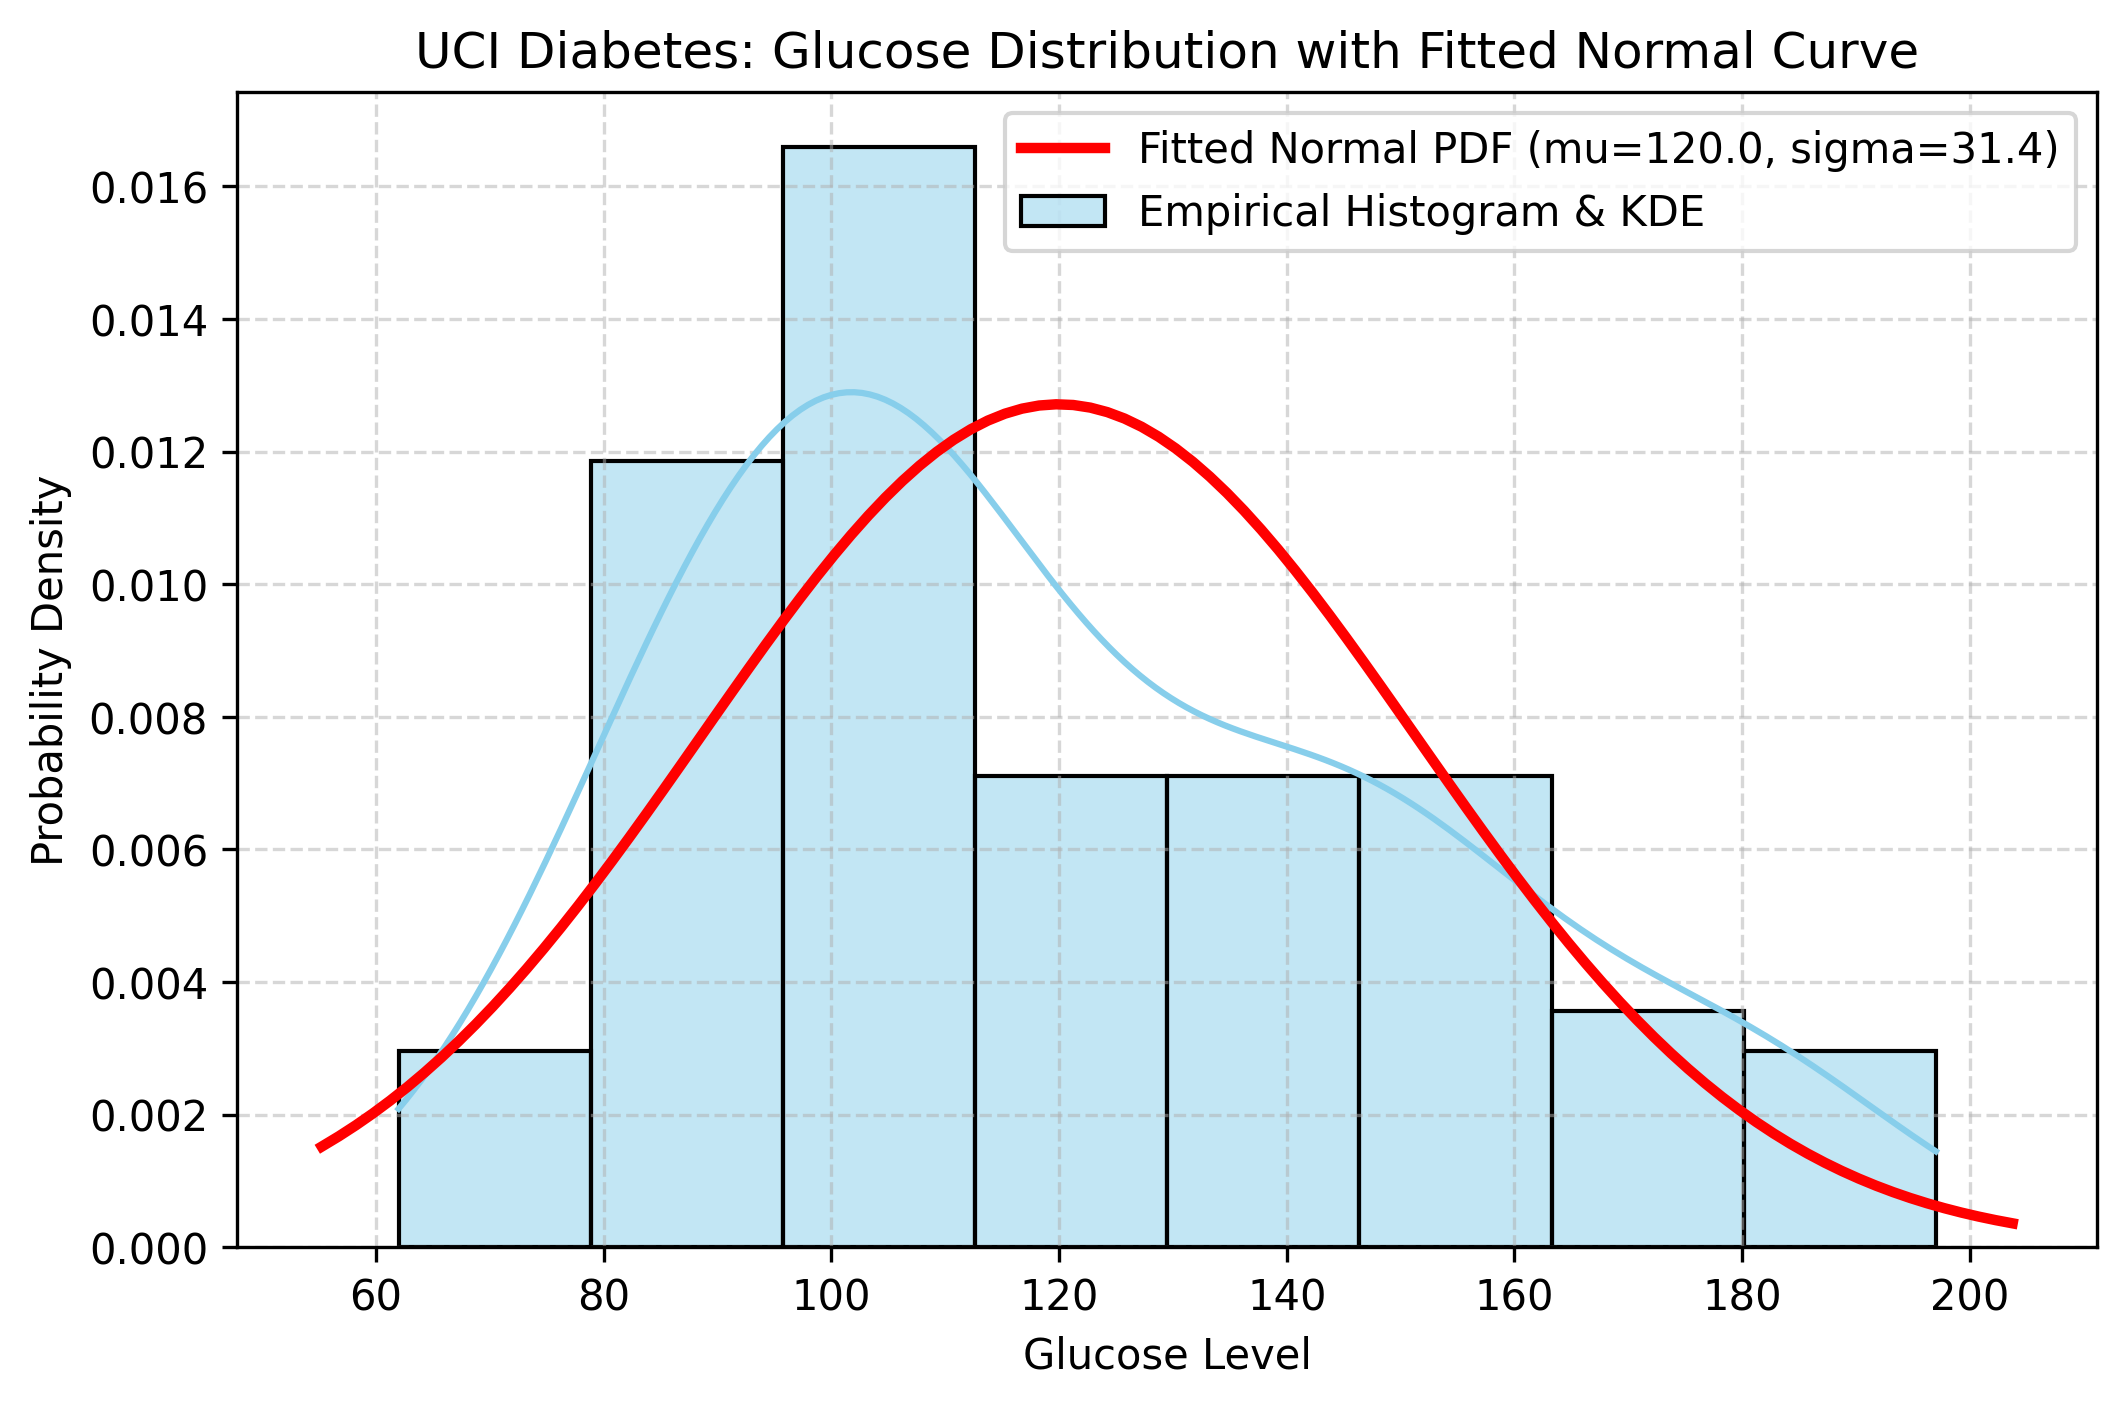

In [2]:
glucose = uci_diabetes['Glucose'].dropna()
mu, std = glucose.mean(), glucose.std()
print(f'Glucose Statistics -> Mean (mu): {mu:.2f}, Std Dev (sigma): {std:.2f}')

plt.figure(figsize=(8, 5))
sns.histplot(glucose, kde=True, stat='density', color='skyblue', edgecolor='black', label='Empirical Histogram & KDE')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2.5, label=f'Fitted Normal PDF (mu={mu:.1f}, sigma={std:.1f})')
plt.title('UCI Diabetes: Glucose Distribution with Fitted Normal Curve')
plt.xlabel('Glucose Level')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. Multi-Feature Normal Curve Fitting Diagnostics

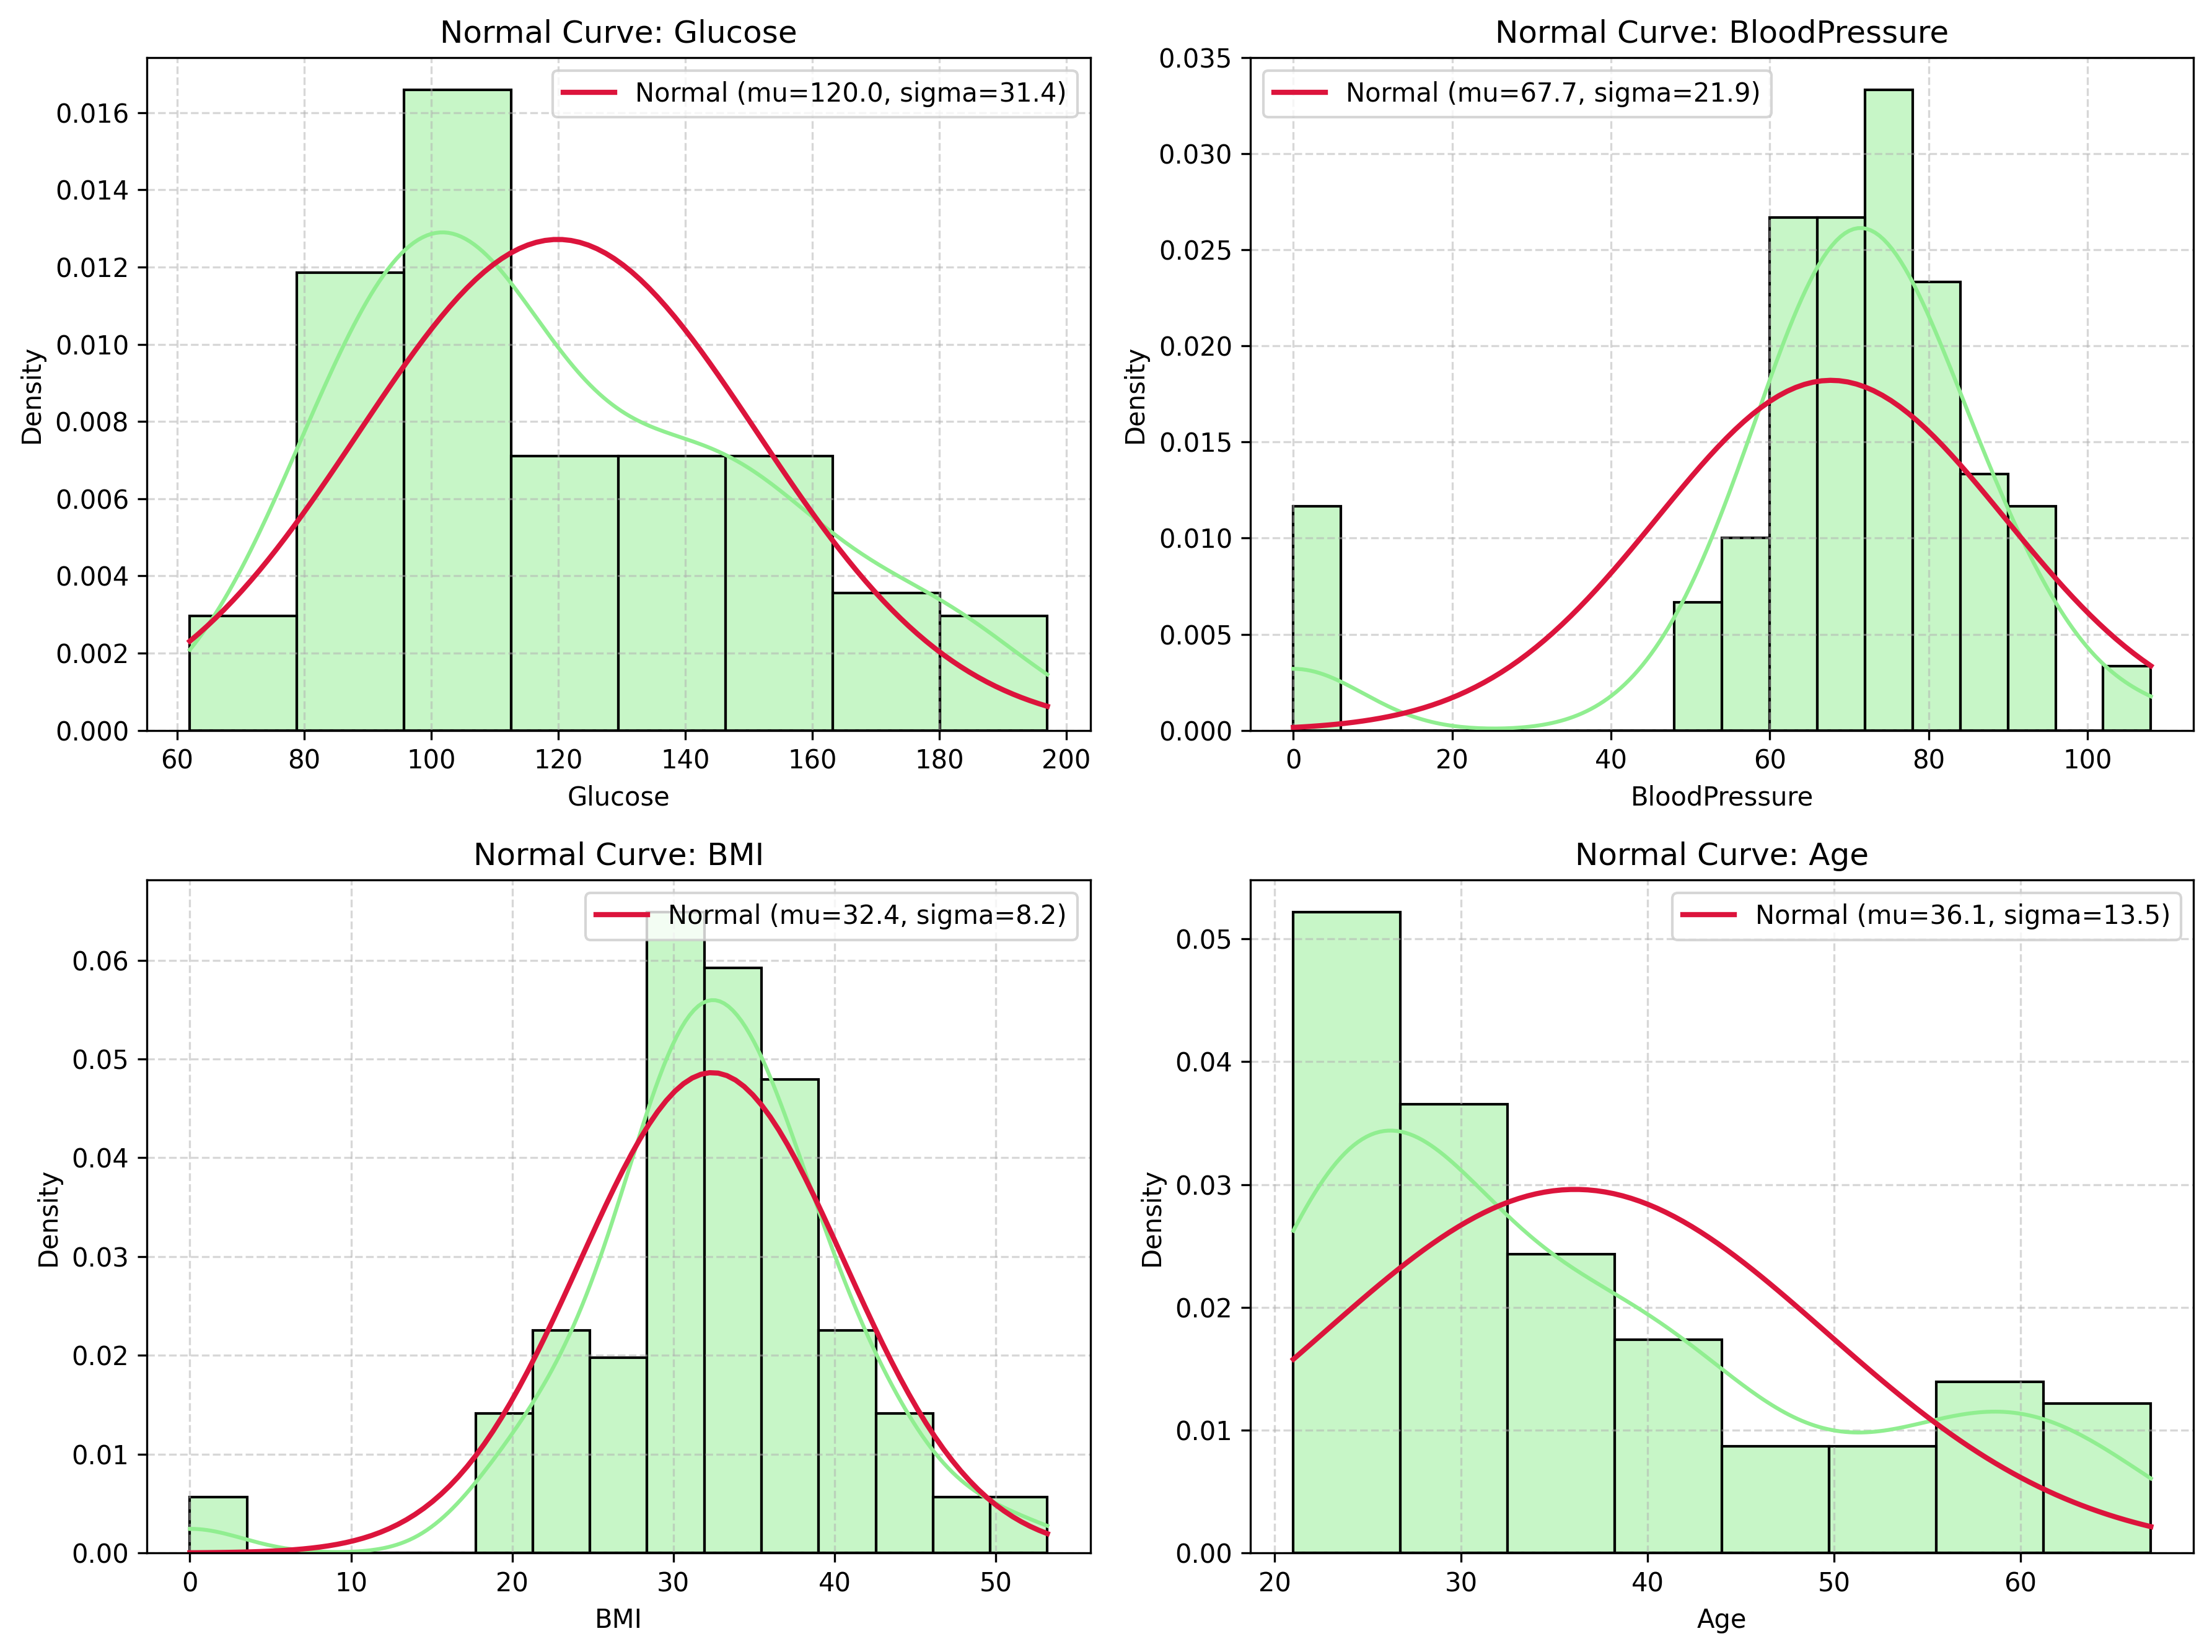

In [3]:
features = ['Glucose', 'BloodPressure', 'BMI', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    data = uci_diabetes[col].dropna()
    m, s = data.mean(), data.std()
    sns.histplot(data, kde=True, stat='density', ax=axes[i], color='lightgreen', edgecolor='black')
    x_vals = np.linspace(data.min(), data.max(), 100)
    axes[i].plot(x_vals, norm.pdf(x_vals, m, s), 'crimson', lw=2, label=f'Normal (mu={m:.1f}, sigma={s:.1f})')
    axes[i].set_title(f'Normal Curve: {col}')
    axes[i].set_xlabel(col)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()